Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid", palette="muted")

In [4]:
df = pd.read_csv('../data/survey_results_public.csv', low_memory=False)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]} ...")

Shape: (49191, 172)
Columns: ['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode', 'LearnCodeAI'] ...


In [5]:
# Câte valori lipsă are fiecare coloană (procentual)
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Top 20 coloane cu valori lipsă (%):")
print(missing.head(20))

Top 20 coloane cu valori lipsă (%):
AIAgentObsWrite         99.463316
SOTagsWant Entry        99.125856
SOTagsHaveEntry         99.068935
AIModelsWantEntry       99.034376
AIAgentOrchWrite        99.028278
JobSatPoints_15_TEXT    98.650160
AIAgentKnowWrite        98.442805
AIModelsHaveEntry       98.422476
SO_Actions_15_TEXT      98.326930
AIAgentExtWrite         98.253746
CommPlatformWantEntr    97.593056
CommPlatformHaveEntr    96.999451
DatabaseWantEntry       96.883576
OfficeStackWantEntry    96.712813
TechOppose_15_TEXT      96.651827
TechEndorse_13_TEXT     95.915920
DevEnvWantEntry         95.706532
DatabaseHaveEntry       95.629282
OfficeStackHaveEntry    94.736842
WebframeWantEntry       94.653494
dtype: float64


In [6]:
print("AIThreat distribution:")
print(df['AIThreat'].value_counts(dropna=False))
print()
print("Procentual:")
print(df['AIThreat'].value_counts(normalize=True, dropna=False).round(3) * 100)

AIThreat distribution:
AIThreat
No              22958
NaN             13113
I'm not sure     7700
Yes              5420
Name: count, dtype: int64

Procentual:
AIThreat
No              46.7
NaN             26.7
I'm not sure    15.7
Yes             11.0
Name: proportion, dtype: float64


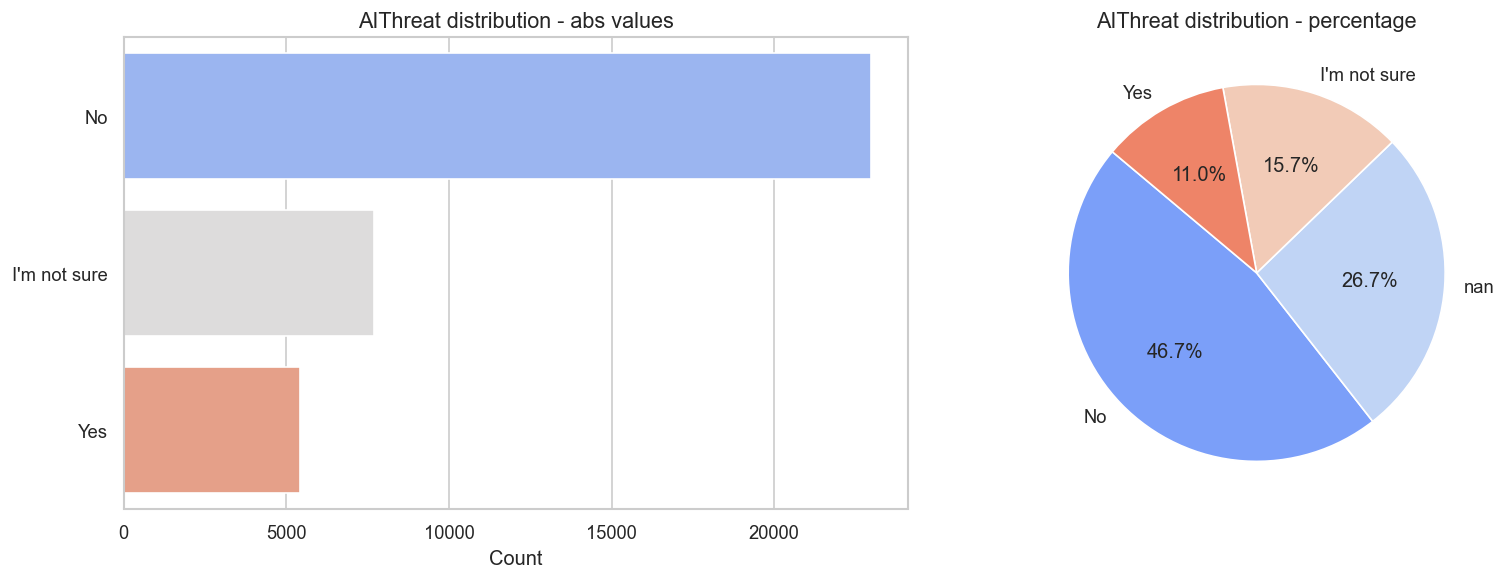

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
order = df['AIThreat'].value_counts().index
sns.countplot(data=df, y='AIThreat', order=order, ax=axes[0], palette='coolwarm')
axes[0].set_title('AIThreat distribution - abs values', fontsize=13)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

# Pie chart
threat_counts = df['AIThreat'].value_counts(dropna=False)
axes[1].pie(
    threat_counts.values,
    labels=threat_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('coolwarm', len(threat_counts)),
    startangle=140
)
axes[1].set_title('AIThreat distribution - percentage', fontsize=13)

plt.tight_layout()
plt.savefig('../reports/figures/01_aithreat_distribution.png', bbox_inches='tight')
plt.show()

- Majoritatea developerilor nu se văd amenințați de AI (aproximativ 47% dintre ei)
- Aproximativ 16% sunt într-o incertitudine privind amenințarea de către AI
- O parte semnificativă dintre respondenți (11%) sunt de părere că AI-ul este o amenințare pentru joburile lor
- Aproape 27% dintre respondenți nu au răspuns la această întrebare, așadar pentru că este un număr ridicat de respondenți care nu au răspuns, îi vom elimina în faza de preprocesare.


<Figure size 1680x840 with 0 Axes>

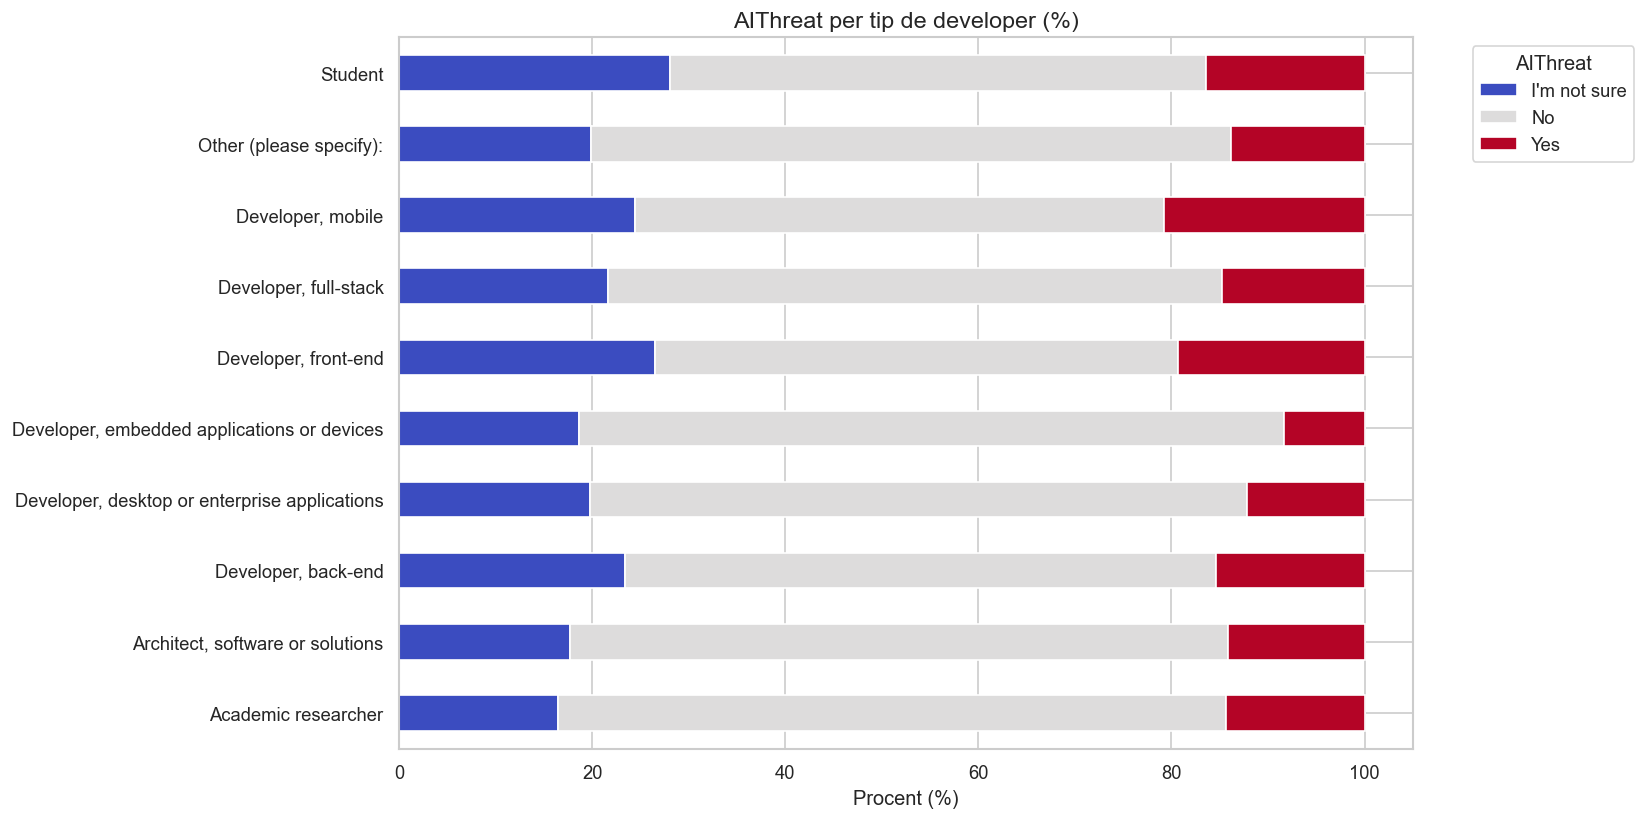

In [8]:
# Explodam coloana multi-label DevType
devtype_df = df[['DevType', 'AIThreat']].dropna()
devtype_df = devtype_df.assign(DevType=devtype_df['DevType'].str.split(';')).explode('DevType')
devtype_df['DevType'] = devtype_df['DevType'].str.strip()

# Top 10 DevType-uri
top_devtypes = devtype_df['DevType'].value_counts().head(10).index
plot_df = devtype_df[devtype_df['DevType'].isin(top_devtypes)]

plt.figure(figsize=(14, 7))
ct = pd.crosstab(plot_df['DevType'], plot_df['AIThreat'], normalize='index') * 100
ct.plot(kind='barh', stacked=True, colormap='coolwarm', figsize=(14, 7))
plt.title('AIThreat per tip de developer (%)', fontsize=14)
plt.xlabel('Procent (%)')
plt.ylabel('')
plt.legend(title='AIThreat', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../reports/figures/02_aithreat_per_devtype.png', bbox_inches='tight')
plt.show()

- Studenții și developerii de tip front-end au cel mai mare procent de incertitudine privind amenințarea de către AI asupra rolurilor lor, în rândul studenților e de înțeles fiind viitorul lor la mijloc, iar în cazul developerilor front-end probabil pentru că taskurile fornt-end sunt mai ușor de automatizat cu AI (UI,CSS,etc)
- Aparent, developerii de tip mobil și front-end pare că se consideră amenințați de AI
În general, în fiecare tip de categorie există peste 15% nivel de incertitudine în rândul respondenților.
Oamenii de știință (Academic researcher) pare că au opinia mai clară având un scor mai mic de incertitudine.

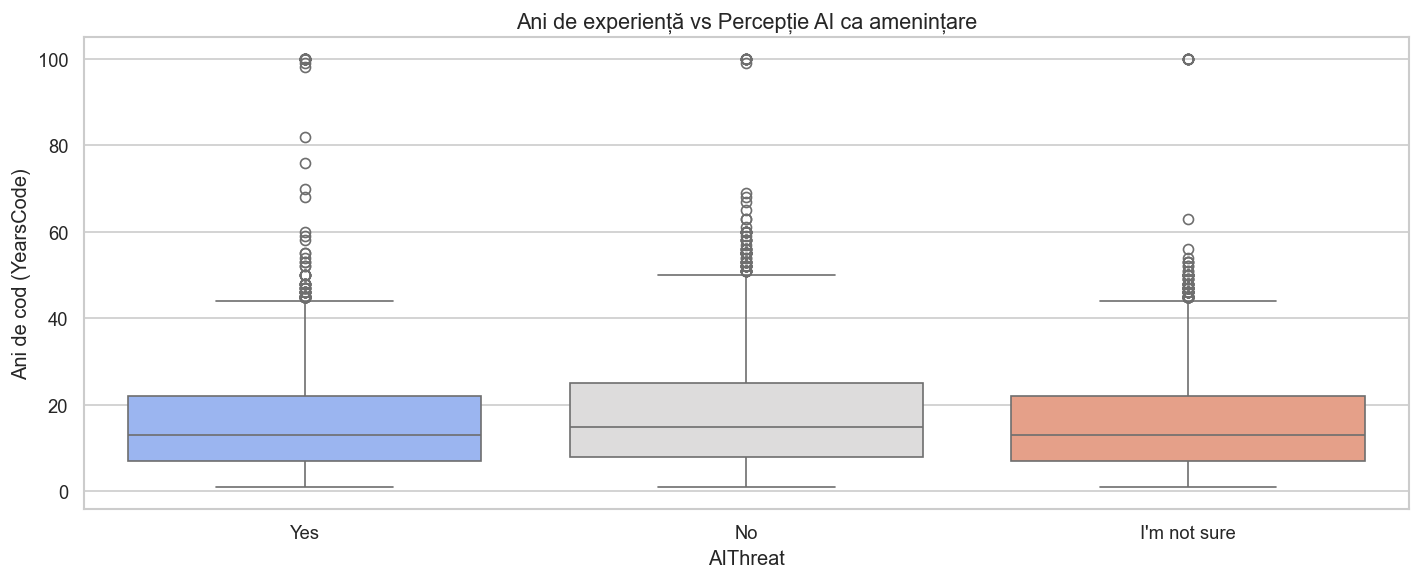

In [9]:
# Curățăm YearsCode
df['YearsCode_clean'] = pd.to_numeric(
    df['YearsCode'].replace({'Less than 1 year': 0, 'More than 50 years': 51}),
    errors='coerce'
)

plt.figure(figsize=(12, 5))
order = ['Yes', 'No', "I'm not sure"]
sns.boxplot(
    data=df[df['AIThreat'].isin(order)],
    x='AIThreat', y='YearsCode_clean',
    order=order, palette='coolwarm'
)
plt.title('Ani de experiență vs Percepție AI ca amenințare', fontsize=13)
plt.xlabel('AIThreat')
plt.ylabel('Ani de cod (YearsCode)')
plt.tight_layout()
plt.savefig('../reports/figures/03_aithreat_yearsCode.png', bbox_inches='tight')
plt.show()

Medianele fiecărui grup pare a fi identică pentru toate cele 3 grupuri, și există outlierii la 100 de ani în toate grupurile, evident erori de completare - de curățat în PREPROCESSING.

YearsCode nu e un predictor puternic pentru AIThreat singur

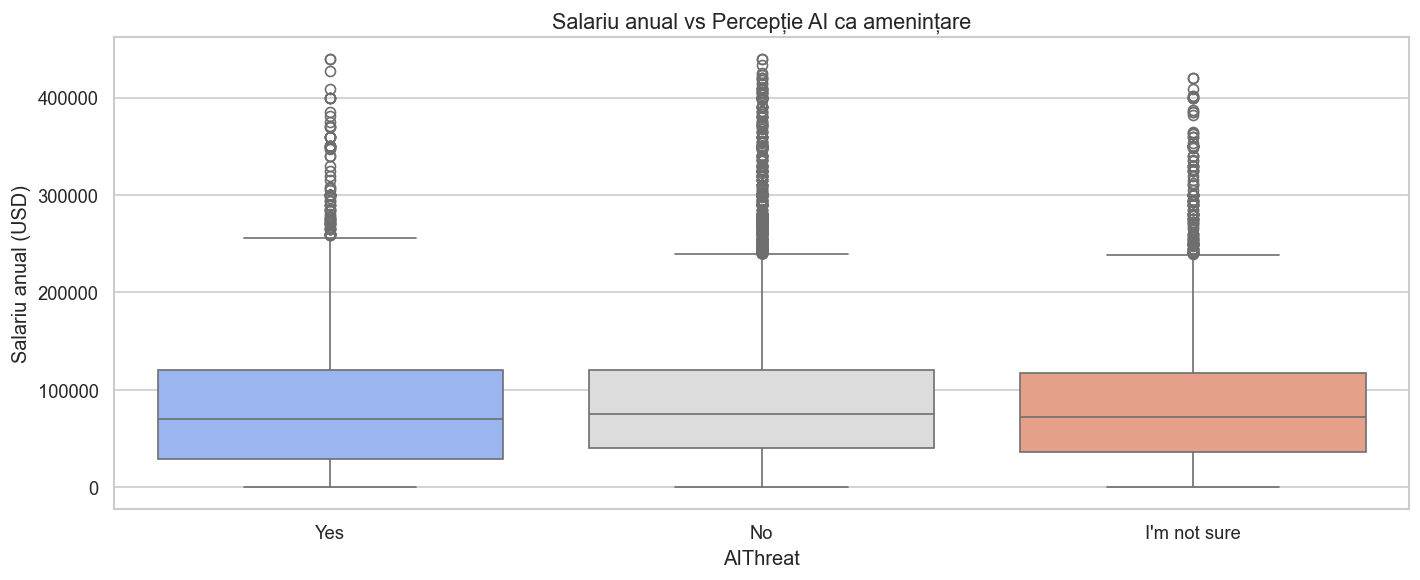

In [10]:
salary_df = df[df['ConvertedCompYearly'] < df['ConvertedCompYearly'].quantile(0.99)].copy()
salary_df = salary_df[salary_df['AIThreat'].isin(['Yes', 'No', "I'm not sure"])]

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=salary_df,
    x='AIThreat', y='ConvertedCompYearly',
    order=['Yes', 'No', "I'm not sure"],
    palette='coolwarm'
)
plt.title('Salariu anual vs Percepție AI ca amenințare', fontsize=13)
plt.xlabel('AIThreat')
plt.ylabel('Salariu anual (USD)')
plt.tight_layout()
plt.savefig('../reports/figures/04_aithreat_salary.png', bbox_inches='tight')
plt.show()

Medianele sunt aproape identice, deci salariul nu diferențiază clar percepția asupra AI ului
Mulți outlieri - logaritmăm aici


Salariul singur nu prezice AIThreat - e cam slab, dar poate contribuie în combinație cu altele

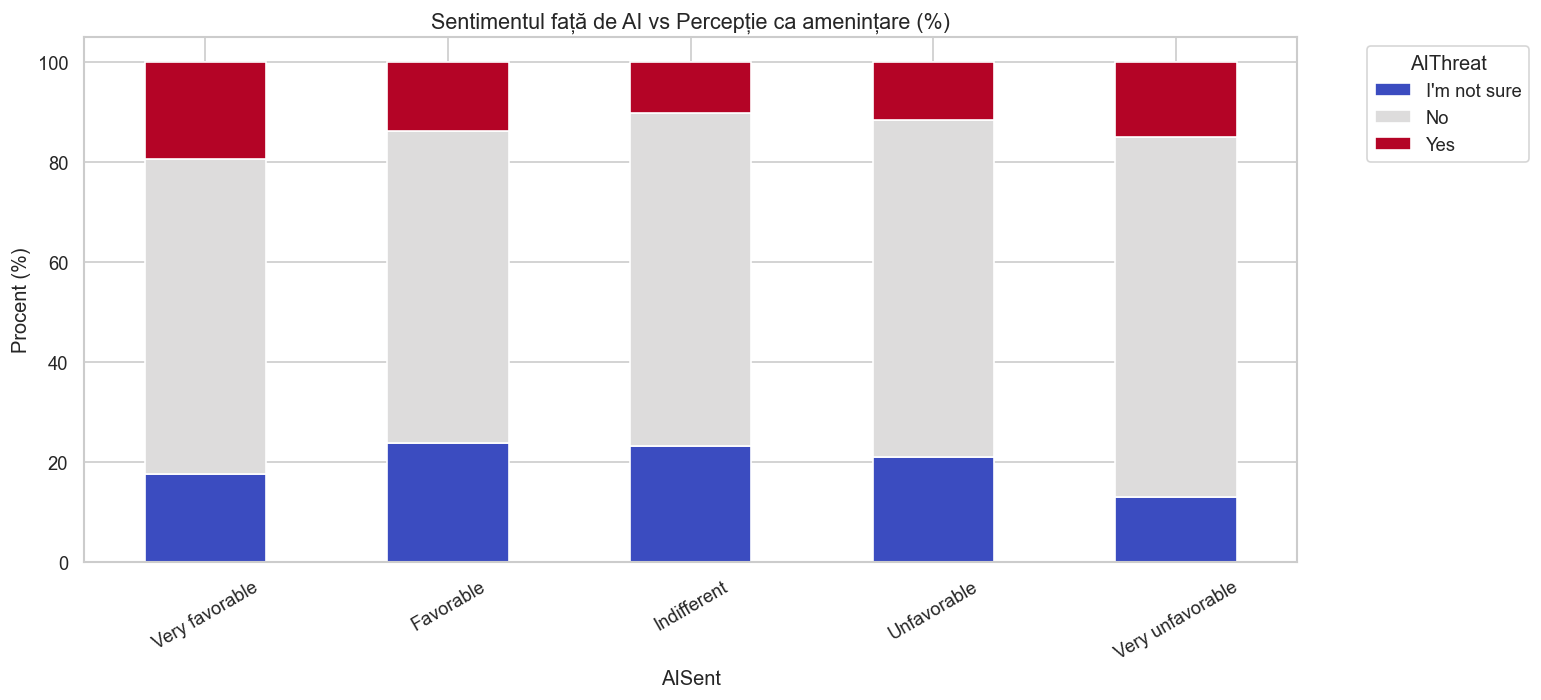

In [11]:
cross = pd.crosstab(df['AISent'], df['AIThreat'], normalize='index') * 100
cross = cross.reindex(['Very favorable', 'Favorable', 'Indifferent', 'Unfavorable', 'Very unfavorable'])

cross.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(13, 6))
plt.title('Sentimentul față de AI vs Percepție ca amenințare (%)', fontsize=13)
plt.xlabel('AISent')
plt.ylabel('Procent (%)')
plt.xticks(rotation=30)
plt.legend(title='AIThreat', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../reports/figures/05_aithreat_per_aisent.png', bbox_inches='tight')
plt.show()

Cel mai mare procent de Yes e în grupa de Very Favorable, deci cei care iubesc AI ul se simt și cei mai amenințați ?? - probabil pentru că știu cât de capabil este să facă task urile lor

very unfavorable - cel mai mic Im not sure și un procent ridicat de da, deci cei care nu iubesc AI ul se simt și ei amenințați, dar mai hotărâți

- diferențele sunt mici între categorii, deci nici acesta nu e un predictor foarte puternic

AISent - AIThreat - nu e neapărat o relație liniară, e poate ceva mai complex

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          20278
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       12589
Some college/university study without earning a degree                                 6182
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     3631
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2624
Associate degree (A.A., A.S., etc.)                                                    1562
Other (please specify):                                                                 701
Primary/elementary school                                                               582
Name: count, dtype: int64


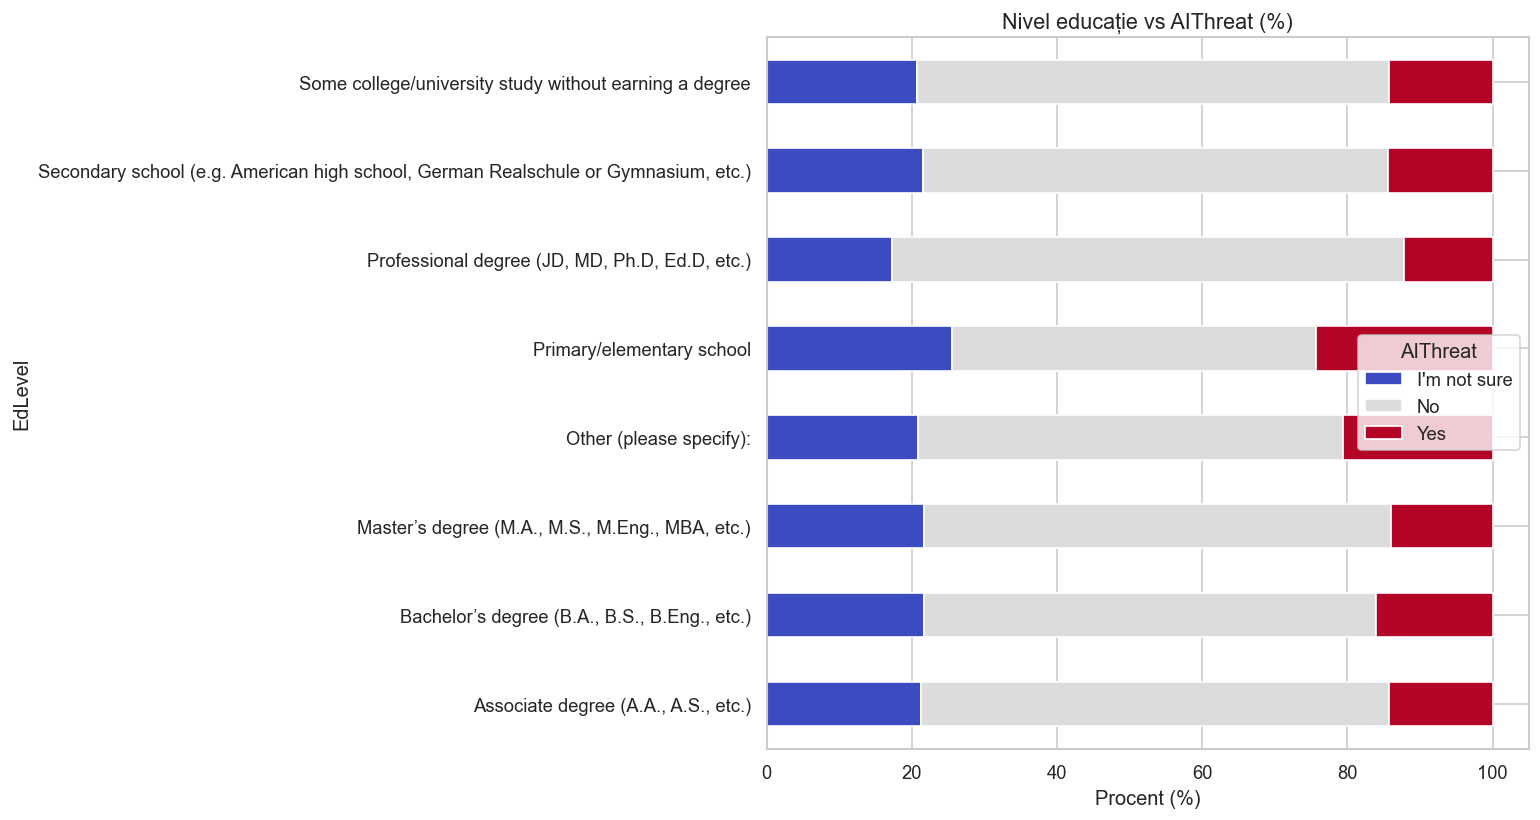

In [12]:
edlevel_order = [
    'EdLevel',
'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',                                          
'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',                                       
'Some college/university study without earning a degree',                                 
'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',    
'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',                                         
'Associate degree (A.A., A.S., etc.)',                                                    
'Other (please specify):',                                                     
'Primary/elementary school'
]

ed_df = df[df['EdLevel'].isin(edlevel_order) & df['AIThreat'].notna()]
cross_ed = pd.crosstab(ed_df['EdLevel'], ed_df['AIThreat'], normalize='index') * 100
# cross_ed = cross_ed.reindex(edlevel_order)
print(df['EdLevel'].value_counts())

cross_ed.plot(kind='barh', stacked=True, colormap='coolwarm', figsize=(13, 7))
plt.title('Nivel educație vs AIThreat (%)', fontsize=13)
plt.xlabel('Procent (%)')
plt.tight_layout()
plt.savefig('../reports/figures/06_aithreat_per_edlevel.png', bbox_inches='tight')
plt.show()

Cei cu educația cea mai precară (primary/elementary school) se simt cei mai amenințați de către AI
Pare că cu cât crește educația, cu atât simțul acesta de amenințare de către AI scade


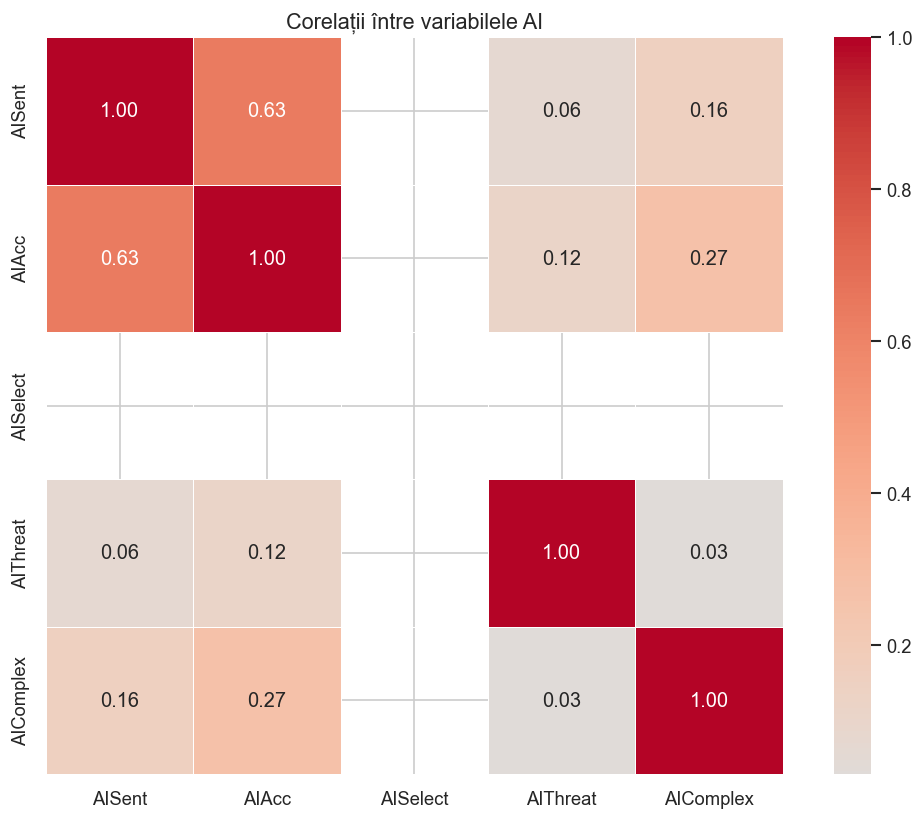

In [13]:
ai_cols = ['AISent', 'AIAcc', 'AISelect', 'AIThreat', 'AIComplex']

# Encoding ordinal simplu pentru heatmap
ordinal_map = {
    'Very favorable': 5, 'Favorable': 4, 'Indifferent': 3,
    'Unfavorable': 2, 'Very unfavorable': 1,
    'Highly trust': 5, 'Somewhat trust': 4, 'Neither trust nor distrust': 3,
    'Somewhat distrust': 2, 'Highly distrust': 1,
    'Yes': 1, 'No': 0, "I'm not sure": 0.5,
    'Good at handling complex tasks': 3,
    'Neither good or bad at handling complex tasks': 2,
    'Bad at handling complex tasks': 1
}

heatmap_df = df[ai_cols].replace(ordinal_map).apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(9, 7))
sns.heatmap(
    heatmap_df.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Corelații între variabilele AI', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/07_ai_correlations_heatmap.png', bbox_inches='tight')
plt.show()

In [14]:
print("=" * 50)
print("SUMMARY EDA — AIThreat")
print("=" * 50)
print(f"\nTotal respondenti: {len(df):,}")
print(f"Respondenti cu AIThreat completat: {df['AIThreat'].notna().sum():,}")
print(f"\nDistributie AIThreat:")
for val, pct in (df['AIThreat'].value_counts(normalize=True)*100).items():
    print(f"  {val:<20} {pct:.1f}%")
print(f"\nFiguri salvate în: reports/figures/")

SUMMARY EDA — AIThreat

Total respondenti: 49,191
Respondenti cu AIThreat completat: 36,078

Distributie AIThreat:
  No                   63.6%
  I'm not sure         21.3%
  Yes                  15.0%

Figuri salvate în: reports/figures/


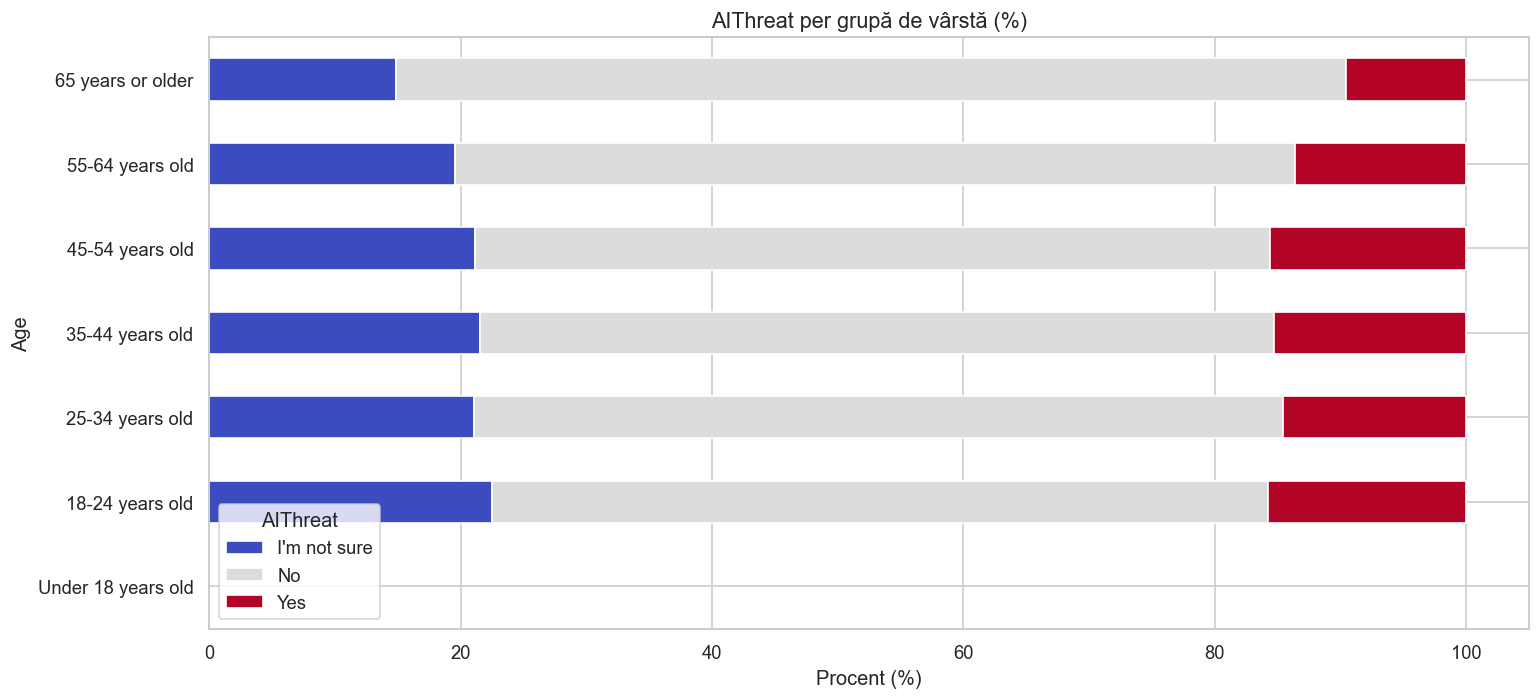

In [15]:
age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old',
    '35-44 years old', '45-54 years old', '55-64 years old',
    '65 years or older'
]

age_df = df[df['Age'].isin(age_order) & df['AIThreat'].notna()]
cross_age = pd.crosstab(age_df['Age'], age_df['AIThreat'], normalize='index') * 100
cross_age = cross_age.reindex(age_order)

cross_age.plot(kind='barh', stacked=True, colormap='coolwarm', figsize=(13, 6))
plt.title('AIThreat per grupă de vârstă (%)', fontsize=13)
plt.xlabel('Procent (%)')
plt.tight_layout()
plt.savefig('../reports/figures/08_aithreat_per_age.png', bbox_inches='tight')
plt.show()

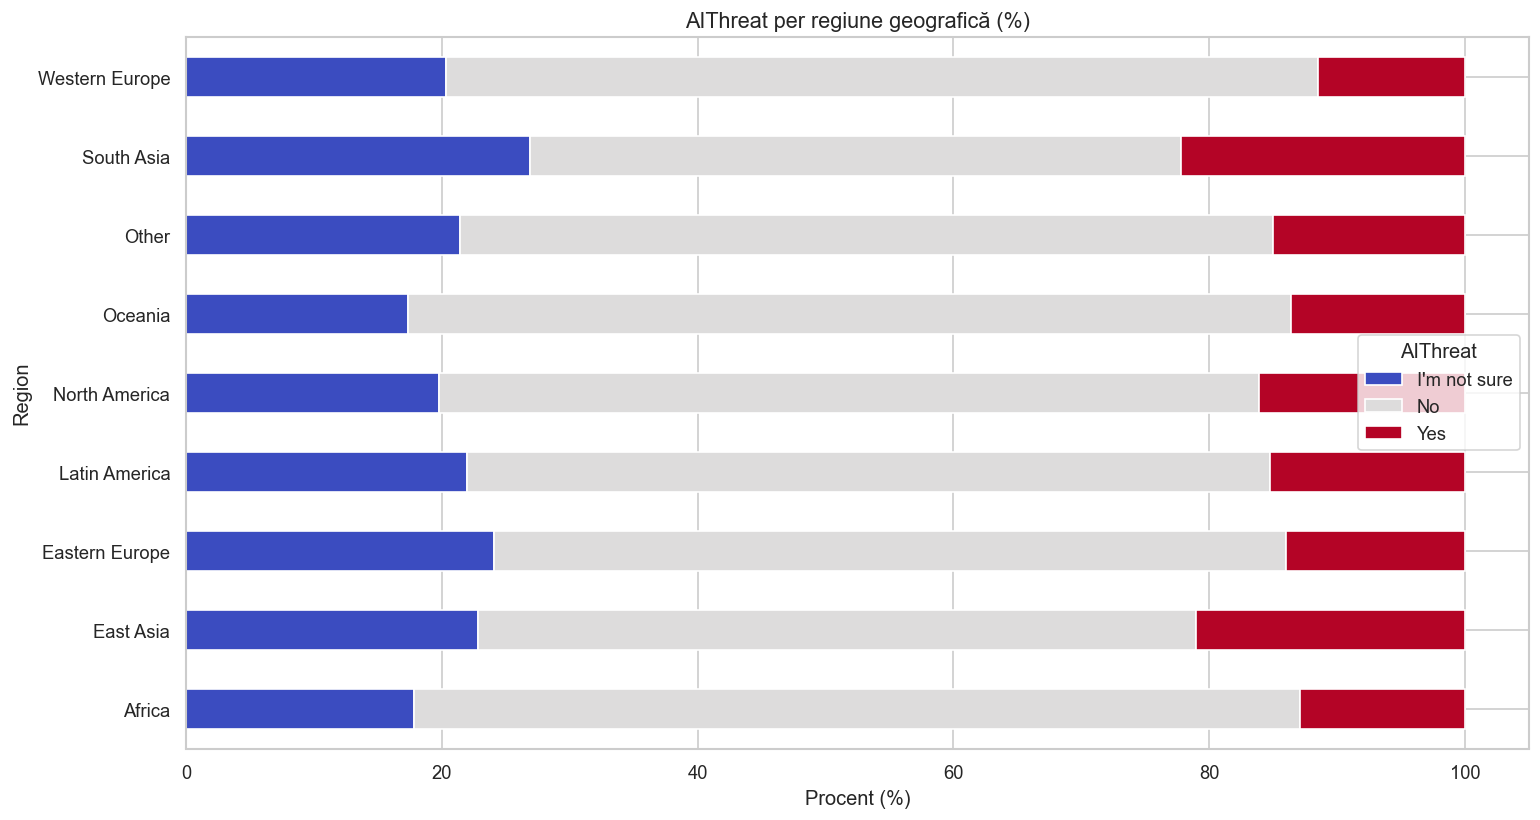

In [16]:
region_map = {
    'United States of America': 'North America',
    'Canada': 'North America',
    'United Kingdom of Great Britain and Northern Ireland': 'Western Europe',
    'Germany': 'Western Europe', 'France': 'Western Europe',
    'Netherlands': 'Western Europe', 'Sweden': 'Western Europe',
    'Poland': 'Eastern Europe', 'Ukraine': 'Eastern Europe',
    'Romania': 'Eastern Europe', 'Czech Republic': 'Eastern Europe',
    'India': 'South Asia', 'Pakistan': 'South Asia',
    'Brazil': 'Latin America', 'Mexico': 'Latin America',
    'Argentina': 'Latin America', 'Colombia': 'Latin America',
    'China': 'East Asia', 'Japan': 'East Asia',
    'South Korea': 'East Asia', 'Australia': 'Oceania',
    'Nigeria': 'Africa', 'South Africa': 'Africa',
}

df['Region'] = df['Country'].map(region_map).fillna('Other')

region_df = df[df['AIThreat'].notna()]
cross_region = pd.crosstab(region_df['Region'], region_df['AIThreat'], normalize='index') * 100

cross_region.plot(kind='barh', stacked=True, colormap='coolwarm', figsize=(13, 7))
plt.title('AIThreat per regiune geografică (%)', fontsize=13)
plt.xlabel('Procent (%)')
plt.tight_layout()
plt.savefig('../reports/figures/09_aithreat_per_region.png', bbox_inches='tight')
plt.show()

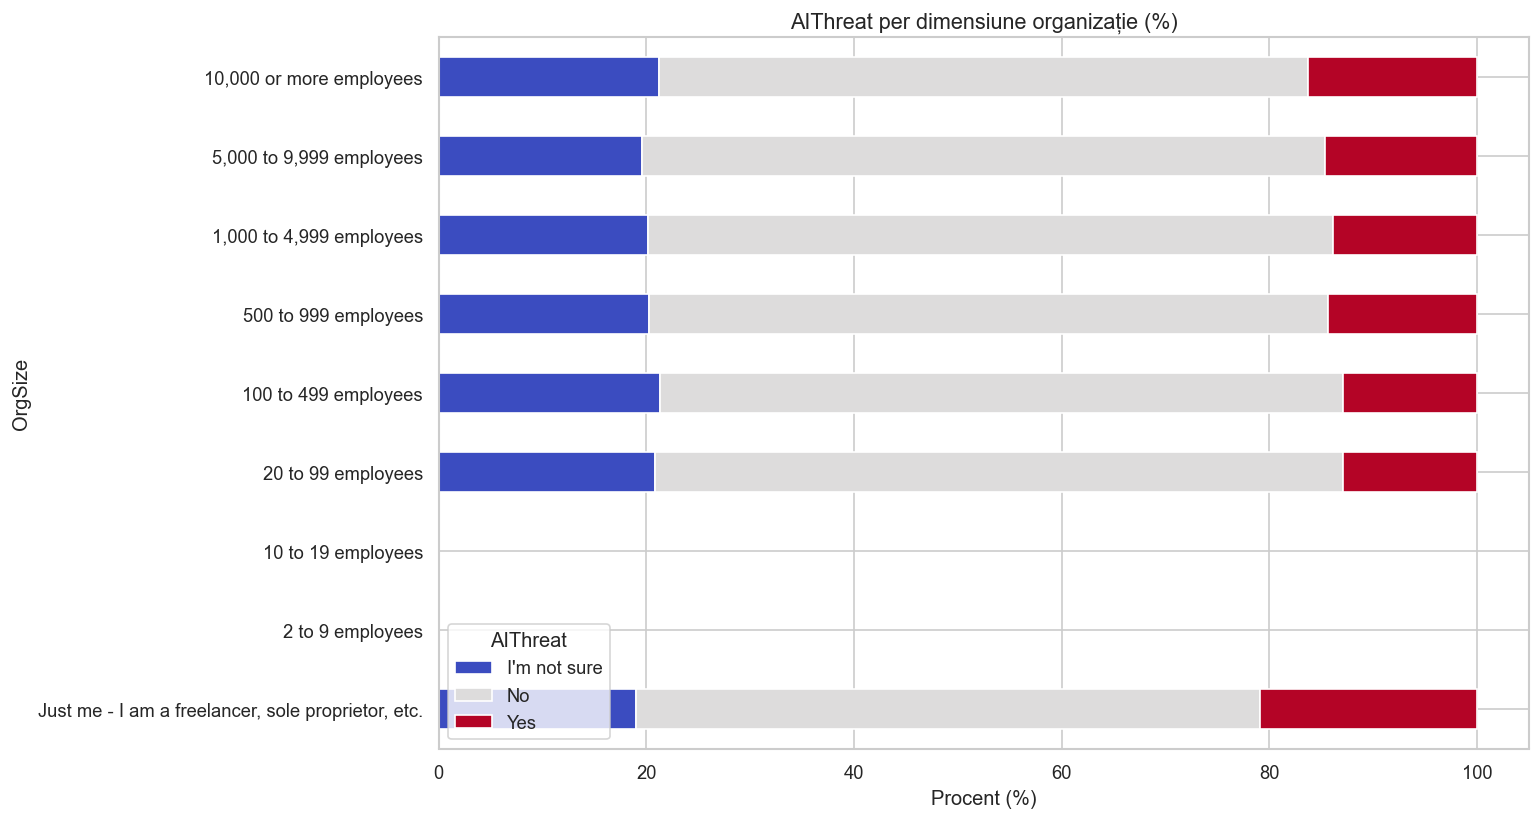

In [17]:
orgsize_order = [
    'Just me - I am a freelancer, sole proprietor, etc.',
    '2 to 9 employees', '10 to 19 employees', '20 to 99 employees',
    '100 to 499 employees', '500 to 999 employees',
    '1,000 to 4,999 employees', '5,000 to 9,999 employees',
    '10,000 or more employees'
]

org_df = df[df['OrgSize'].isin(orgsize_order) & df['AIThreat'].notna()]
cross_org = pd.crosstab(org_df['OrgSize'], org_df['AIThreat'], normalize='index') * 100
cross_org = cross_org.reindex(orgsize_order)

cross_org.plot(kind='barh', stacked=True, colormap='coolwarm', figsize=(13, 7))
plt.title('AIThreat per dimensiune organizație (%)', fontsize=13)
plt.xlabel('Procent (%)')
plt.tight_layout()
plt.savefig('../reports/figures/10_aithreat_per_orgsize.png', bbox_inches='tight')
plt.show()

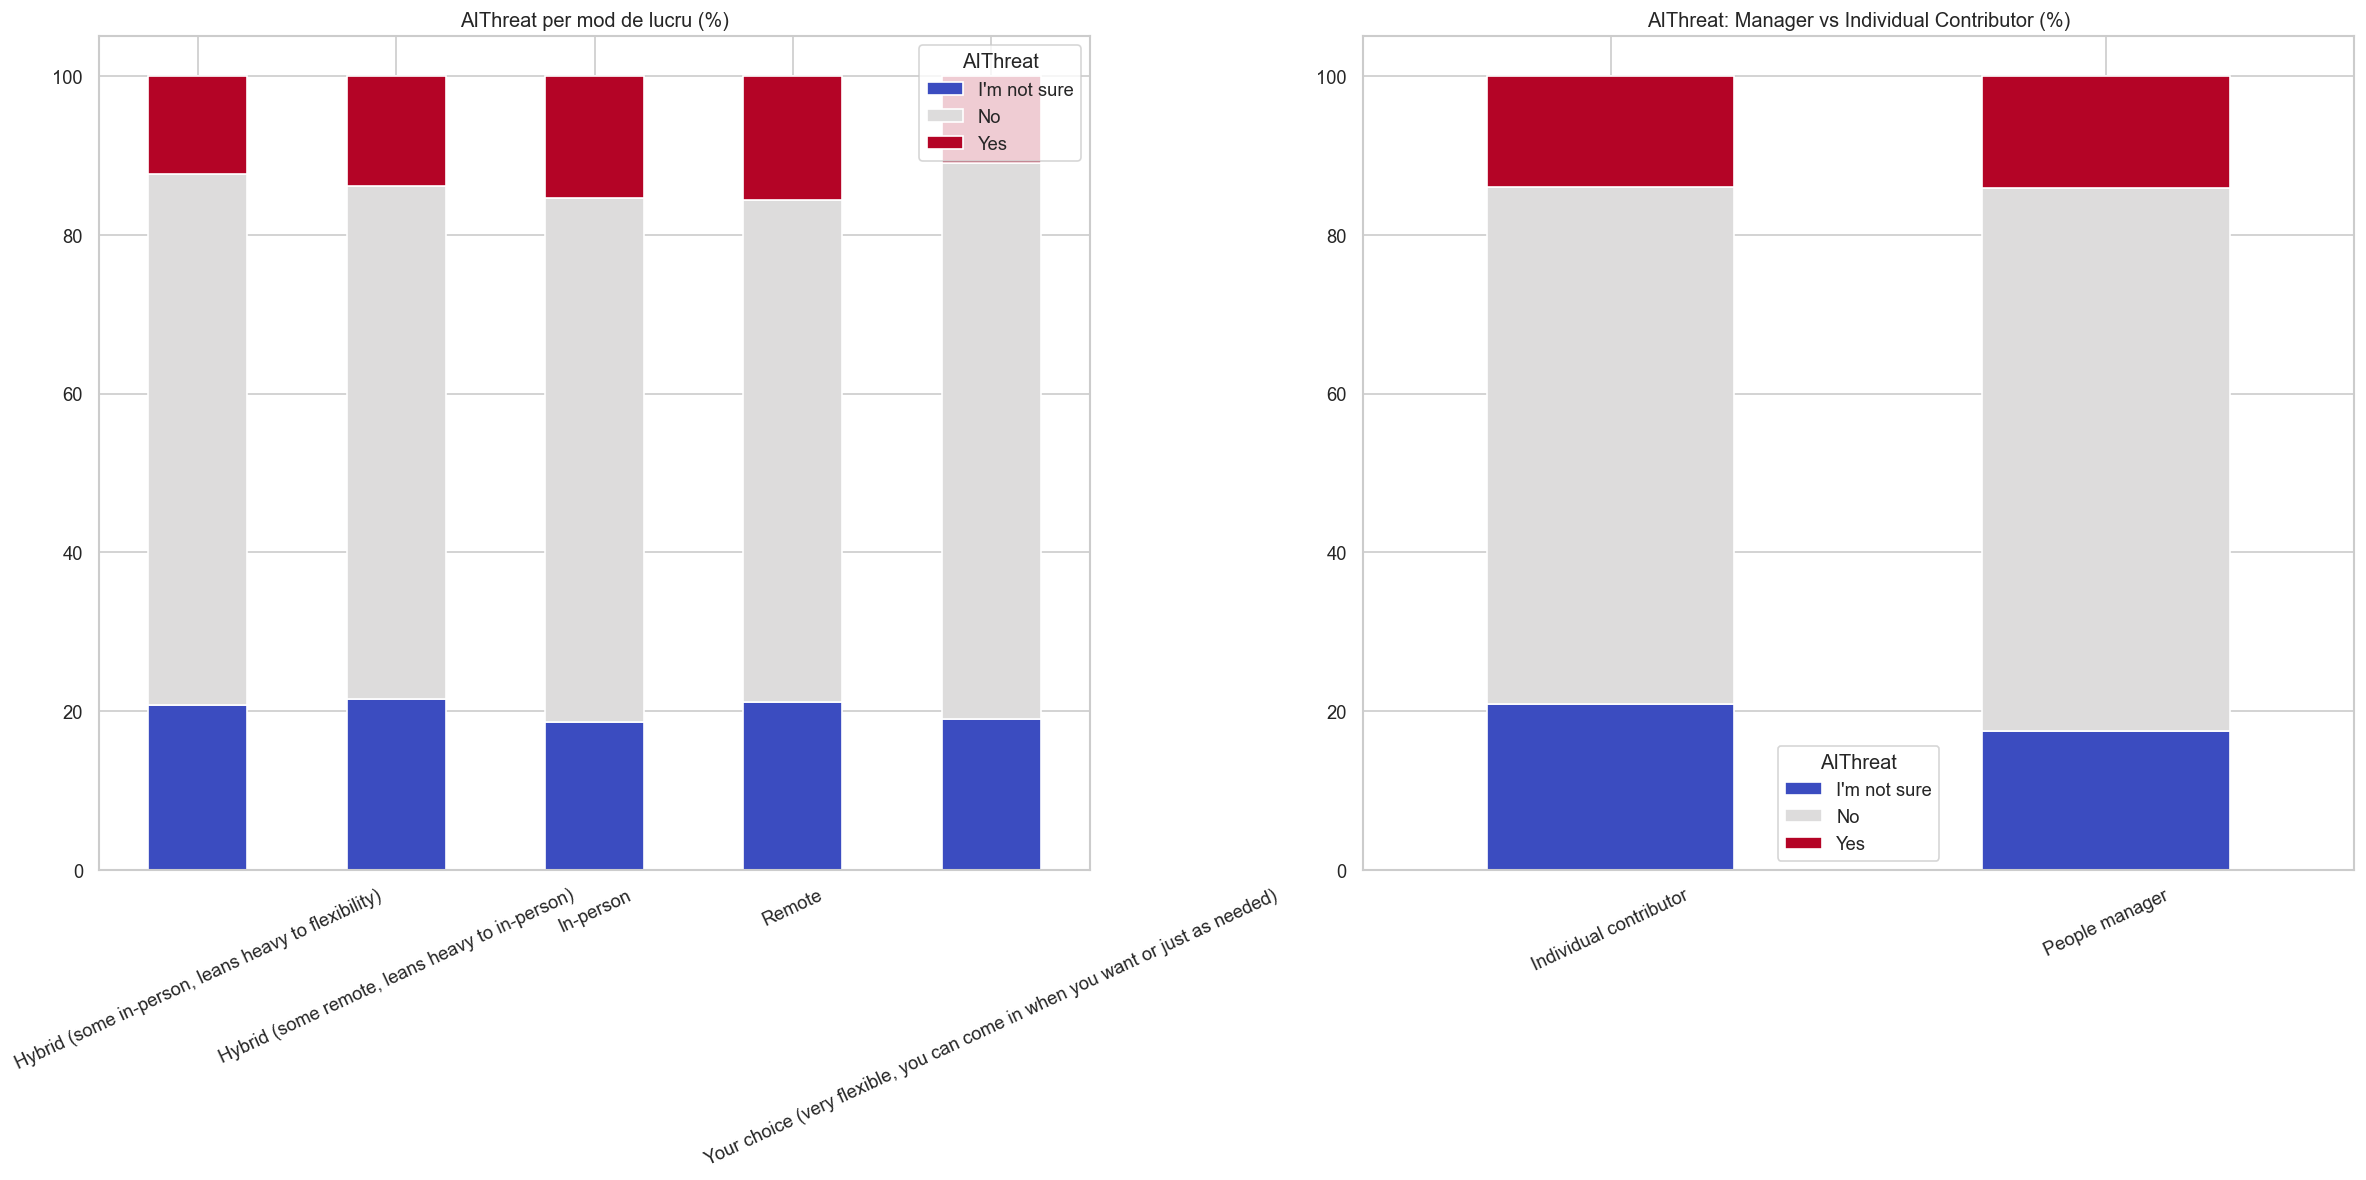

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# RemoteWork
remote_df = df[df['AIThreat'].notna() & df['RemoteWork'].notna()]
cross_remote = pd.crosstab(remote_df['RemoteWork'], remote_df['AIThreat'], normalize='index') * 100
cross_remote.plot(kind='bar', stacked=True, colormap='coolwarm', ax=axes[0])
axes[0].set_title('AIThreat per mod de lucru (%)', fontsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

# ICorPM
pm_df = df[df['AIThreat'].notna() & df['ICorPM'].notna()]
cross_pm = pd.crosstab(pm_df['ICorPM'], pm_df['AIThreat'], normalize='index') * 100
cross_pm.plot(kind='bar', stacked=True, colormap='coolwarm', ax=axes[1])
axes[1].set_title('AIThreat: Manager vs Individual Contributor (%)', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('../reports/figures/11_aithreat_remote_pm.png', bbox_inches='tight')
plt.show()

In [19]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


c:\Users\gabri\Desktop\Personal Projects\ai-threat-perception-stackoverflow\venv\Scripts\python.exe: No module named pip


In [21]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
classes = ['Yes', 'No', "I'm not sure"]
colors = ['Reds', 'Blues', 'Greys']

for ax, cls, cmap in zip(axes, classes, colors):
    texts = df[df['AIThreat'] == cls]['AIFrustration'].dropna().str.cat(sep=' ')
    if texts.strip():
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap=cmap,
            max_words=80,
            collocations=False
        ).generate(texts)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'AIFrustration — AIThreat: {cls}', fontsize=12)
    ax.axis('off')

plt.suptitle('Cuvinte frecvente în AIFrustration per clasă', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/12_wordcloud_aifrustration.png', bbox_inches='tight')
plt.show()

ModuleNotFoundError: No module named 'wordcloud'